<div class="output_png output_subarea output_execute_result">
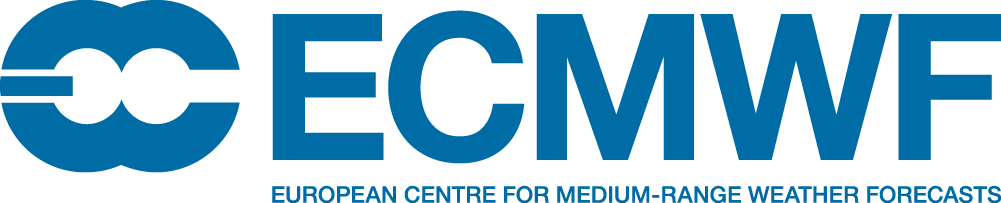
</div>

# 	AIFS ENS Probabilities: 24hr total precipitation

This notebook will provide you with guidance on how to explore and plot the ECMWF open dataset to produce the map from the ECMWF Open Charts web product.  
The original product can be found at this link: https://charts.ecmwf.int/products/aifs_ens_medium-tp-probability 


<div class="output_png output_subarea output_execute_result">
<center>
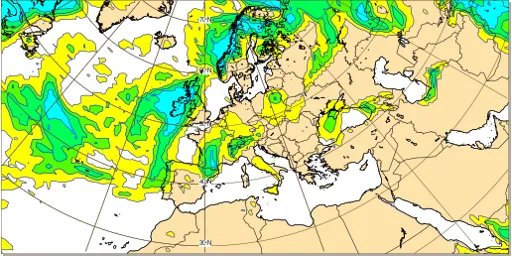</center>
</div>

The full list of available AIFS Open Data products can be found [here](https://www.ecmwf.int/en/forecasts/dataset/aifs-machine-learning-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF AIFS data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain access to the full forecast dataset at higher resolution, please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes one of 7 parameters as input:

* [Total precipitation of at least 1 mm](https://codes.ecmwf.int/grib/param-db/131060)
* [Total precipitation of at least 5 mm](https://codes.ecmwf.int/grib/param-db/131061)
* [Total precipitation of at least 10 mm](https://codes.ecmwf.int/grib/param-db/131062)
* [Total precipitation of at least 20 mm](https://codes.ecmwf.int/grib/param-db/131063)
* [Total precipitation of at least 25 mm](https://codes.ecmwf.int/grib/param-db/131098)
* [Total precipitation of at least 50 mm](https://codes.ecmwf.int/grib/param-db/131099)
* [Total precipitation of at least 100 mm](https://codes.ecmwf.int/grib/param-db/131085)

In this example, we will use: 
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data 

First, we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on the three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-opendata

In [1]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [ ]:
client = Client("ecmwf", beta=False, model="aifs-ens")

In [3]:
parameters = ['tpg1','tpg5','tpg10','tpg20','tpg25','tpg50','tpg100']
filename = 'aifs_ens_medium-tp-probability.grib'
filename

'aifs_ens_medium-tp-probability.grib'

<div class="alert alert-block alert-success">
Note that this parameter has a slightly different step than most other parameters.  
Since this parameter is the probability of the total precipitation exceeding a threshold in a 24-hour period, the step is the interval between the beginning and the end of the period.
</div>

Setting "date" to 0 will download today's data. 
Removing "date" and "time" altogether from the request will download the latest data.  
Try commenting out the date and time to download the latest forecast!

In [4]:
client.retrieve(
    date=-1,
    time=0,
    step="120-144",
    stream="enfo",
    type="ep",
    levtype="sfc",
    param=parameters,
    target=filename
)

20260729000000-240h-enfo-ep.grib2:   0%|          | 0.00/1.83M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


## Reading and processing the data
Now we can use **Metview's read() function** to read the file.

In [5]:
data = mv.read(filename)

The **describe()** function will give us the overview of the dataset.  

In [6]:
data.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
tpg1,surface,0,20260729,0,144,None,131060,ai,enfo,ep,0001
tpg10,surface,0,20260729,0,144,None,131062,ai,enfo,ep,0001
tpg100,surface,0,20260729,0,144,None,131085,ai,enfo,ep,0001
tpg20,surface,0,20260729,0,144,None,131063,ai,enfo,ep,0001
tpg25,surface,0,20260729,0,144,None,131098,ai,enfo,ep,0001
tpg5,surface,0,20260729,0,144,None,131061,ai,enfo,ep,0001
tpg50,surface,0,20260729,0,144,None,131099,ai,enfo,ep,0001


And specifying the parameter shortName in the describe function, we can get more detailed information about the data.

In [7]:
data.describe('tpg20')

shortName,tpg20
name,Total precipitation of at least 20 mm
paramId,131063
units,%
typeOfLevel,surface
level,0
date,20260729
time,0
step,144
number,None
class,ai


We can use **ls()** function to list all the fields in the file we downloaded.

In [8]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
Message,,,,,,,,,,
0,ecmf,tpg25,surface,0,20260729,0,120-144,ep,None,regular_ll
1,ecmf,tpg100,surface,0,20260729,0,120-144,ep,None,regular_ll
2,ecmf,tpg50,surface,0,20260729,0,120-144,ep,None,regular_ll
3,ecmf,tpg20,surface,0,20260729,0,120-144,ep,None,regular_ll
4,ecmf,tpg5,surface,0,20260729,0,120-144,ep,None,regular_ll
5,ecmf,tpg10,surface,0,20260729,0,120-144,ep,None,regular_ll
6,ecmf,tpg1,surface,0,20260729,0,120-144,ep,None,regular_ll


The grib file contains all the parameters, and we will use the **select()** function to filter one of them.

In [9]:
data_tpg1 = data.select(shortName= "tpg1")
data_tpg5 = data.select(shortName= "tpg5")
data_tpg10 = data.select(shortName= "tpg10")
data_tpg20 = data.select(shortName= "tpg20")
data_tpg10.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
tpg10,surface,0,20260729,0,144,None,131062,ai,enfo,ep,0001


## Plotting the data
And finally, we can plot the data on the map. 

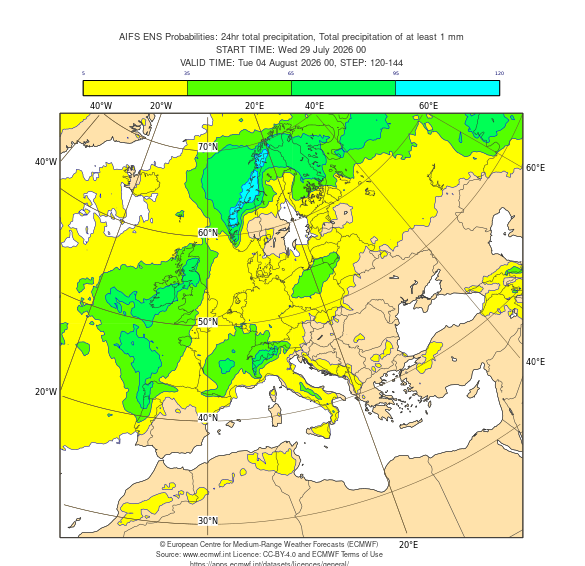

In [10]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
data_tpg1_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_grn_f0t100lst")

title = mv.mtext(
    text_lines=["AIFS ENS Probabilities: 24hr total precipitation, <grib_info key='name'/>",
                "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
                "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H' />, STEP: <grib_info key='step'/>"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, data_tpg1, data_tpg1_shade, title, ecmwf_text)

To generate the png file you can run the following cell.

In [13]:
png = mv.png_output(
      output_name = "aifs_ens_medium-tp-probability",   # specify relative or full path
      output_title = "aifs_ens_medium-tp-probability",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, data_tpg1, data_tpg1_shade, title, ecmwf_text)

Note that the plot produced using the open data dataset will slightly differ from the one in Open Charts. This is due to the different resolution of the data.  
Open Data has a 0.25x0.25 resolution, while the high-resolution data has a 0.1x0.1 grid.